<a href="https://colab.research.google.com/github/shreyoshi2304/Attention/blob/main/triparite_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

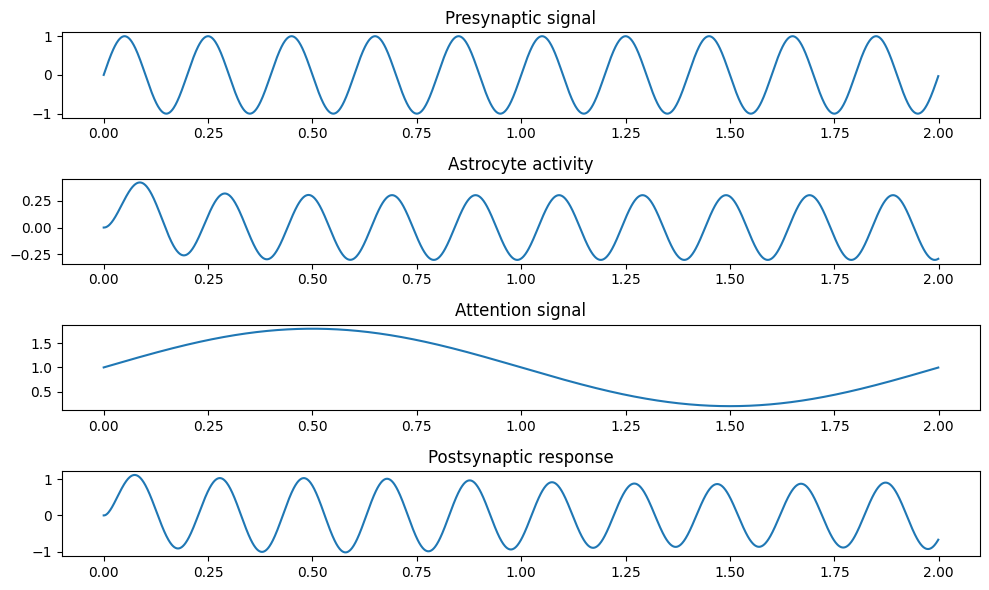

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Time
T = 2
dt = 0.001
t = np.arange(0, T, dt)

# Presynaptic activity (input signal)
pre = np.sin(2 * np.pi * 5 * t)

# Astrocyte dynamics
astro = np.zeros(len(t))
tau_astro = 0.1

# Postsynaptic neuron
post = np.zeros(len(t))
tau_post = 0.02

# Attention signal (modulates astrocyte)
attention = 1 + 0.8 * np.sin(2 * np.pi * 0.5 * t)

# Synaptic weights
w_syn = 1.0
w_astro = 0.8

for i in range(len(t) - 1):

    # Astrocyte integrates presynaptic activity
    dA = (-astro[i] + pre[i]) / tau_astro
    astro[i+1] = astro[i] + dt * dA

    # Astrocyte modulation (attention-controlled)
    astro_modulation = attention[i] * astro[i]

    # Postsynaptic input (tripartite interaction)
    syn_input = w_syn * pre[i] + w_astro * astro_modulation

    # Postsynaptic dynamics
    dV = (-post[i] + syn_input) / tau_post
    post[i+1] = post[i] + dt * dV

# Plot
plt.figure(figsize=(10,6))

plt.subplot(4,1,1)
plt.plot(t, pre)
plt.title("Presynaptic signal")

plt.subplot(4,1,2)
plt.plot(t, astro)
plt.title("Astrocyte activity")

plt.subplot(4,1,3)
plt.plot(t, attention)
plt.title("Attention signal")

plt.subplot(4,1,4)
plt.plot(t, post)
plt.title("Postsynaptic response")

plt.tight_layout()
plt.show()

Baseline Fano: 0.984256634499397
Attention Fano: 0.9894570279424215


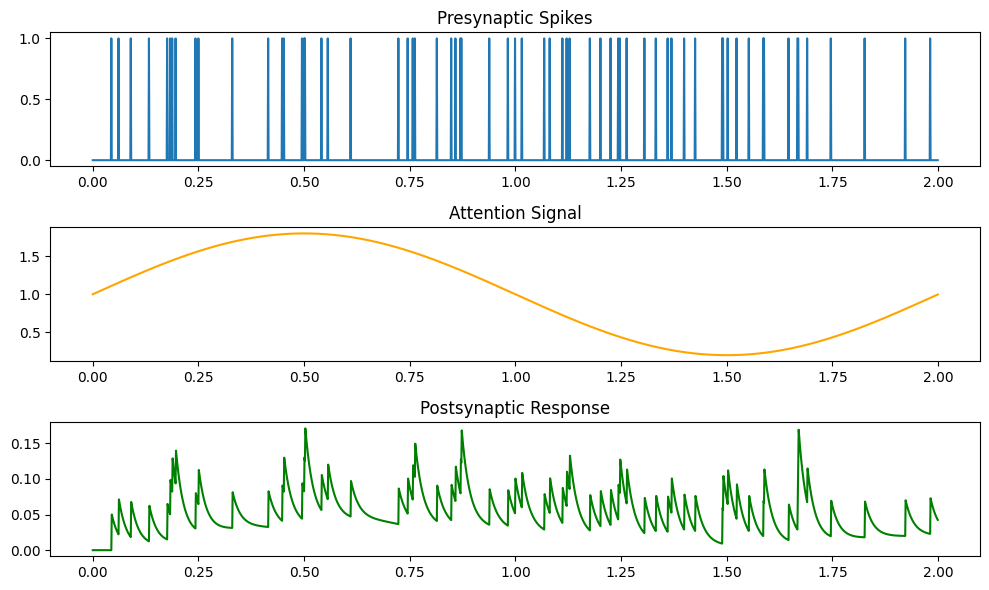

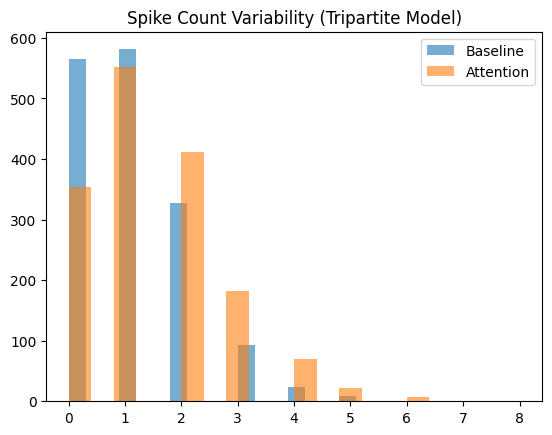

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# =========================
# TIME
# =========================
T = 2.0
dt = 0.001
t = np.arange(0, T, dt)

# =========================
# PARAMETERS
# =========================
base_rate = 20  # Hz
tau_post = 0.02
tau_astro = 0.1
tau_ca = 0.2

w_syn = 1.0
w_astro = 0.8

n_trials = 40
bin_size = 50  # for Fano factor

# =========================
# ATTENTION SIGNAL
# =========================
attention = 1 + 0.8 * np.sin(2 * np.pi * 0.5 * t)

# =========================
# FUNCTIONS
# =========================
def poisson_spikes(rate):
    return np.random.rand(len(t)) < rate * dt

def fano_factor(counts):
    return np.var(counts) / np.mean(counts)

# =========================
# SINGLE TRIAL SIMULATION
# =========================
def run_trial(att_gain=1.0):

    # presynaptic spikes
    rate = att_gain * base_rate
    spikes = poisson_spikes(rate)

    # state variables
    astro = np.zeros(len(t))
    ca = np.zeros(len(t))
    post = np.zeros(len(t))

    for i in range(len(t)-1):

        # -----------------
        # Astrocyte calcium dynamics
        # -----------------
        dca = (-ca[i] + spikes[i]) / tau_ca
        ca[i+1] = ca[i] + dt * dca

        # Astrocyte integrates calcium
        dA = (-astro[i] + ca[i]) / tau_astro
        astro[i+1] = astro[i] + dt * dA

        # -----------------
        # Attention-modulated astrocyte
        # -----------------
        astro_mod = attention[i] * astro[i]

        # -----------------
        # Postsynaptic input
        # -----------------
        syn_input = w_syn * spikes[i] + w_astro * astro_mod

        dV = (-post[i] + syn_input) / tau_post
        post[i+1] = post[i] + dt * dV

    return spikes, post

# =========================
# MULTI-TRIAL VARIABILITY
# =========================
def run_experiment(att_gain):
    all_counts = []

    for _ in range(n_trials):
        spikes, post = run_trial(att_gain)

        # bin spike counts
        counts = np.add.reduceat(spikes, np.arange(0, len(spikes), bin_size))
        all_counts.extend(counts)

    return np.array(all_counts)

# =========================
# RUN CONDITIONS
# =========================
baseline_counts = run_experiment(att_gain=1.0)
attention_counts = run_experiment(att_gain=1.5)

# =========================
# FANO FACTOR
# =========================
fano_baseline = fano_factor(baseline_counts)
fano_attention = fano_factor(attention_counts)

print("Baseline Fano:", fano_baseline)
print("Attention Fano:", fano_attention)

# =========================
# PLOTS
# =========================

# Example trial
spikes, post = run_trial(att_gain=1.5)

plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(t, spikes, label="Spikes")
plt.title("Presynaptic Spikes")

plt.subplot(3,1,2)
plt.plot(t, attention, label="Attention", color='orange')
plt.title("Attention Signal")

plt.subplot(3,1,3)
plt.plot(t, post, label="Postsynaptic", color='green')
plt.title("Postsynaptic Response")

plt.tight_layout()
plt.show()

# Variability distribution
plt.figure()
plt.hist(baseline_counts, bins=20, alpha=0.6, label="Baseline")
plt.hist(attention_counts, bins=20, alpha=0.6, label="Attention")
plt.legend()
plt.title("Spike Count Variability (Tripartite Model)")
plt.show()


--- FANO FACTORS ---
Neuron-only baseline: 0.9763501381215469
Neuron-only attention: 0.9588572393020357
Tripartite baseline: 0.9664530012187689
Tripartite attention: 0.9750624470787467




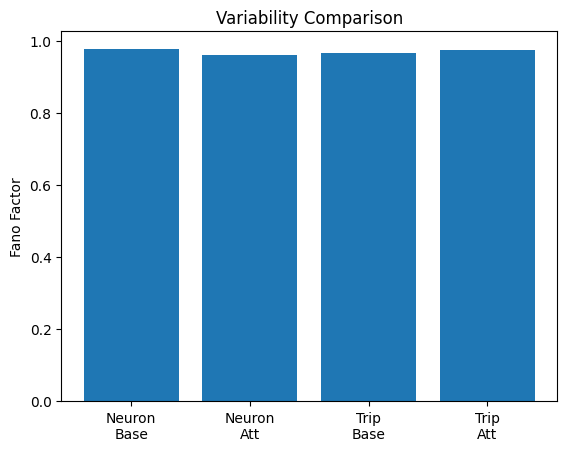

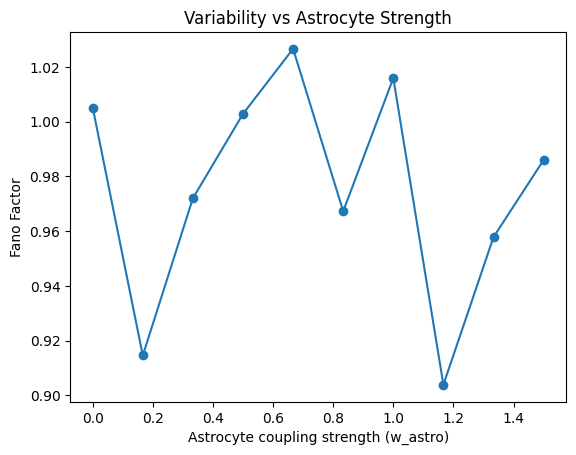

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)

# =========================
# TIME
# =========================
T = 2.0
dt = 0.001
t = np.arange(0, T, dt)

# =========================
# PARAMETERS
# =========================
base_rate = 20
tau_post = 0.02
tau_astro = 0.1
tau_ca = 0.2

n_trials = 40
bin_size = 50

# Attention signal
attention = 1 + 0.8 * np.sin(2 * np.pi * 0.5 * t)

# =========================
# HELPERS
# =========================
def poisson_spikes(rate):
    return np.random.rand(len(t)) < rate * dt

def fano_factor(counts):
    return np.var(counts) / np.mean(counts)

# =========================
# NEURON-ONLY MODEL
# =========================
def run_neuron_only(att_gain=1.0):

    rate = att_gain * base_rate
    spikes = poisson_spikes(rate)

    post = np.zeros(len(t))

    for i in range(len(t)-1):
        dV = (-post[i] + spikes[i]) / tau_post
        post[i+1] = post[i] + dt * dV

    return spikes, post

# =========================
# TRIPARTITE MODEL
# =========================
def run_tripartite(att_gain=1.0, w_astro=0.8):

    rate = att_gain * base_rate
    spikes = poisson_spikes(rate)

    astro = np.zeros(len(t))
    ca = np.zeros(len(t))
    post = np.zeros(len(t))

    for i in range(len(t)-1):

        # Calcium dynamics
        dca = (-ca[i] + spikes[i]) / tau_ca
        ca[i+1] = ca[i] + dt * dca

        # Astrocyte integration
        dA = (-astro[i] + ca[i]) / tau_astro
        astro[i+1] = astro[i] + dt * dA

        # Attention-modulated astrocyte
        astro_mod = attention[i] * astro[i]

        # Synaptic input
        syn_input = spikes[i] + w_astro * astro_mod

        dV = (-post[i] + syn_input) / tau_post
        post[i+1] = post[i] + dt * dV

    return spikes, post

# =========================
# MULTI-TRIAL EXPERIMENT
# =========================
def run_experiment(model_func, att_gain=1.0, w_astro=0.8):

    all_counts = []

    for _ in range(n_trials):
        spikes, _ = model_func(att_gain) if model_func == run_neuron_only \
            else model_func(att_gain, w_astro)

        counts = np.add.reduceat(spikes, np.arange(0, len(spikes), bin_size))
        all_counts.extend(counts)

    return np.array(all_counts)

# =========================
# 1. COMPARISON
# =========================
baseline_neuron = run_experiment(run_neuron_only, att_gain=1.0)
attention_neuron = run_experiment(run_neuron_only, att_gain=1.5)

baseline_trip = run_experiment(run_tripartite, att_gain=1.0)
attention_trip = run_experiment(run_tripartite, att_gain=1.5)

print("\n--- FANO FACTORS ---")
print("Neuron-only baseline:", fano_factor(baseline_neuron))
print("Neuron-only attention:", fano_factor(attention_neuron))
print("Tripartite baseline:", fano_factor(baseline_trip))
print("Tripartite attention:", fano_factor(attention_trip))
print("\n")
# =========================
# Plot comparison
# =========================
plt.figure()
plt.bar(
    ["Neuron\nBase", "Neuron\nAtt", "Trip\nBase", "Trip\nAtt"],
    [
        fano_factor(baseline_neuron),
        fano_factor(attention_neuron),
        fano_factor(baseline_trip),
        fano_factor(attention_trip),
    ]
)
plt.ylabel("Fano Factor")
plt.title("Variability Comparison")
plt.show()
print("\n")
# =========================
# 2. PARAMETER SWEEP (astro strength)
# =========================
astro_strengths = np.linspace(0, 1.5, 10)
fano_values = []

for w in astro_strengths:
    counts = run_experiment(run_tripartite, att_gain=1.5, w_astro=w)
    fano_values.append(fano_factor(counts))

# =========================
# Plot sweep
# =========================
plt.figure()
plt.plot(astro_strengths, fano_values, 'o-')
plt.xlabel("Astrocyte coupling strength (w_astro)")
plt.ylabel("Fano Factor")
plt.title("Variability vs Astrocyte Strength")
plt.show()